# Sustainability comparison — generator experiments

Compares the compute cost of the diffuser/generator experiments. **Energy is estimated from wall-clock time on the RTX 5060 Ti** (`energy = hours × 0.170 kW`), because CodeCarbon does not model that GPU correctly and its `energy_kwh` field is unreliable here. Only real runs (elapsed > 60 s) are kept, which removes the empty CodeCarbon restart appends. Classifier consumption is out of scope. The `02_sd21_filtered` generation cost is a controlled 100-image measurement (its historical log conflated generation into filtering); `05_ldm_basic` is an abandoned dead end with no reliable log and is omitted.

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/utility'))
import pandas as pd
import matplotlib.pyplot as plt
from sustainability_registry import load_events, deduplicate_canonical_events

POWER_KW = 0.170          # measured mean draw of the RTX 5060 Ti during real generation
MIN_SECONDS = 60          # keep only real runs, drop CodeCarbon empty-restart appends
POOL = 1361               # canonical synthetic pool per generator
FIGURES = ROOT / 'results/5_sustainability/figures'; FIGURES.mkdir(parents=True, exist_ok=True)

events = deduplicate_canonical_events(load_events(ROOT / 'results/5_sustainability/canonical_events.jsonl'))
frame = pd.DataFrame(events)
frame['generator'] = frame['experiment_id'].str.replace(r'_sampling_.*$', '', regex=True)
frame['elapsed_seconds'] = pd.to_numeric(frame['elapsed_seconds'], errors='coerce')
real = frame[frame['elapsed_seconds'] > MIN_SECONDS].copy()
real['hours'] = real['elapsed_seconds'] / 3600.0
real['energy_kwh'] = real['hours'] * POWER_KW

# 02_sd21_filtered generation was measured directly (100 images, 100 steps) on the 5060 Ti.
g02 = json.loads((ROOT / 'results/5_sustainability/g02_generation_timing.json').read_text())
g02_gen_hours = g02['seconds_per_image'] * POOL / 3600.0
{'real_runs': len(real), 'dropped': len(frame) - len(real), 'g02_s_per_img': g02['seconds_per_image']}

{'real_runs': 63, 'dropped': 111, 'g02_s_per_img': 7.302}

## 1. Compute time and time-based energy per generator

In [2]:
PHASES = ['generator_training', 'generation', 'filtering', 'validation']
GENS = ['01_sd21_baseline_50steps', '02_sd21_filtered_100steps', '03_sd21_vae_finetuned',
        '04_sd21_lora', '06_ldm_extra1361_fromscratch', '07_ldm_sdvae_extra1361', '08_ldm_v3_sdvae_fromscratch']
by_phase = (real[real['generator'].isin(GENS)].groupby(['generator', 'phase'])['hours'].sum()
            .unstack(fill_value=0.0).reindex(index=GENS, columns=PHASES, fill_value=0.0))
# override 02 generation with the measured value (historical log put it under filtering)
by_phase.loc['02_sd21_filtered_100steps', 'generation'] = g02_gen_hours
totals = pd.DataFrame({'hours': by_phase.sum(axis=1)})
totals['energy_kwh'] = totals['hours'] * POWER_KW
totals = totals.sort_values('energy_kwh', ascending=False)
totals.round(3)

,hours,energy_kwh
generator,,
03_sd21_vae_finetuned,35.526,6.039
06_ldm_extra1361_fromscratch,26.356,4.481
08_ldm_v3_sdvae_fromscratch,13.420,2.281
07_ldm_sdvae_extra1361,11.599,1.972
02_sd21_filtered_100steps,8.618,1.465
04_sd21_lora,8.178,1.390
01_sd21_baseline_50steps,3.219,0.547


## 2. Total time-based energy

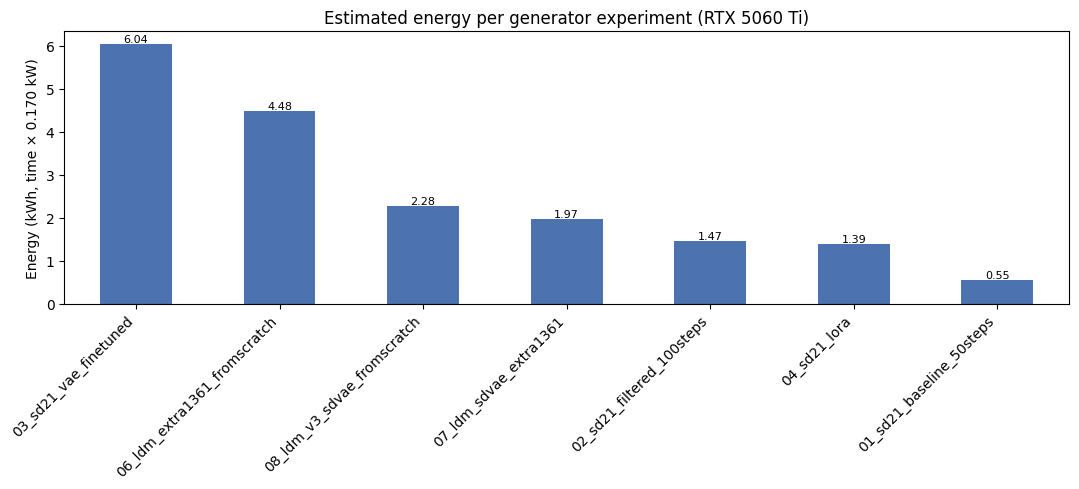

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
totals['energy_kwh'].plot.bar(ax=ax, color='#4C72B0')
ax.set_ylabel('Energy (kWh, time × 0.170 kW)'); ax.set_xlabel('')
ax.set_title('Estimated energy per generator experiment (RTX 5060 Ti)')
for i, v in enumerate(totals['energy_kwh']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
ax.tick_params(axis='x', labelrotation=45)
for lab in ax.get_xticklabels(): lab.set_ha('right')
fig.tight_layout(); fig.savefig(FIGURES / 'generator_energy_total.png', dpi=110)
gcf = fig

## 3. Where the time goes — decomposition by phase

phase,generator_training,generation,filtering,validation
generator,,,,
03_sd21_vae_finetuned,2.596,2.006,0.000,1.437
06_ldm_extra1361_fromscratch,4.126,0.227,0.071,0.056
08_ldm_v3_sdvae_fromscratch,1.171,0.982,0.098,0.030
07_ldm_sdvae_extra1361,1.135,0.820,0.009,0.008
02_sd21_filtered_100steps,0.000,0.469,0.996,0.000
04_sd21_lora,0.836,0.403,0.000,0.151
01_sd21_baseline_50steps,0.367,0.158,0.000,0.022


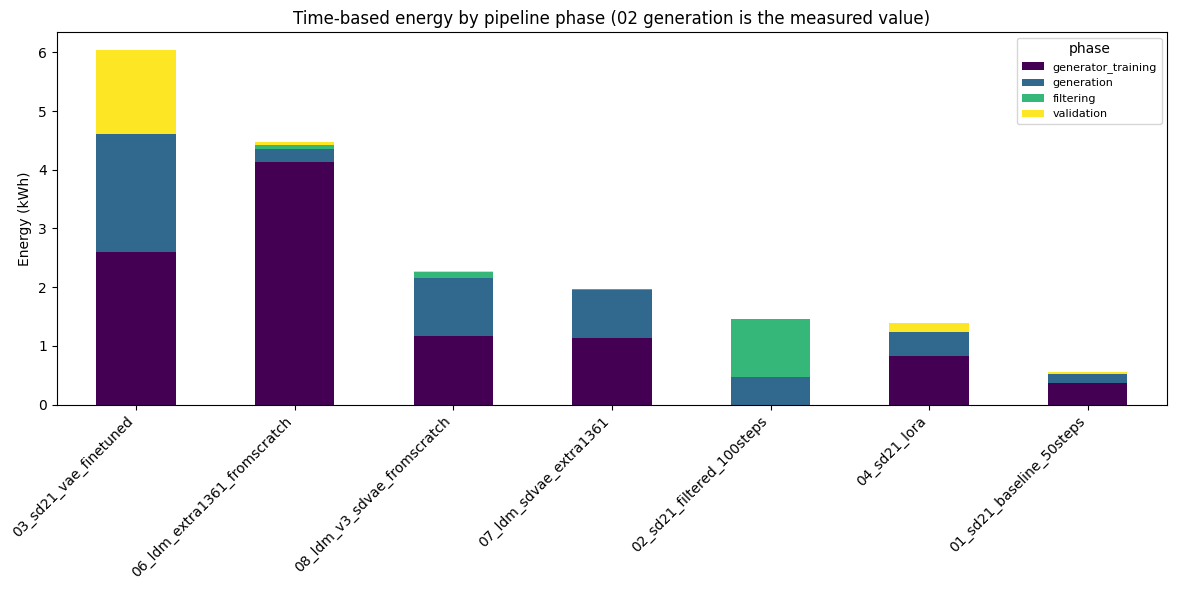

In [4]:
energy_by_phase = (by_phase * POWER_KW).loc[totals.index]
fig, ax = plt.subplots(figsize=(12, 6))
energy_by_phase.plot.bar(stacked=True, ax=ax, colormap='viridis')
ax.set_ylabel('Energy (kWh)'); ax.set_xlabel('')
ax.set_title('Time-based energy by pipeline phase (02 generation is the measured value)')
ax.legend(title='phase', fontsize=8); ax.tick_params(axis='x', labelrotation=45)
for lab in ax.get_xticklabels(): lab.set_ha('right')
fig.tight_layout(); fig.savefig(FIGURES / 'generator_energy_by_phase.png', dpi=110)
energy_by_phase.round(3)

## 4. Generation efficiency

Generation energy for the canonical 1361-image pool. `02` uses the controlled measurement (100 images at 100 steps); the others use their real generation runs.

,generation_hours,generation_kwh
generator,,
03_sd21_vae_finetuned,11.801,2.006
06_ldm_extra1361_fromscratch,1.338,0.227
08_ldm_v3_sdvae_fromscratch,5.779,0.982
07_ldm_sdvae_extra1361,4.825,0.820
02_sd21_filtered_100steps,2.761,0.469
04_sd21_lora,2.371,0.403
01_sd21_baseline_50steps,0.931,0.158


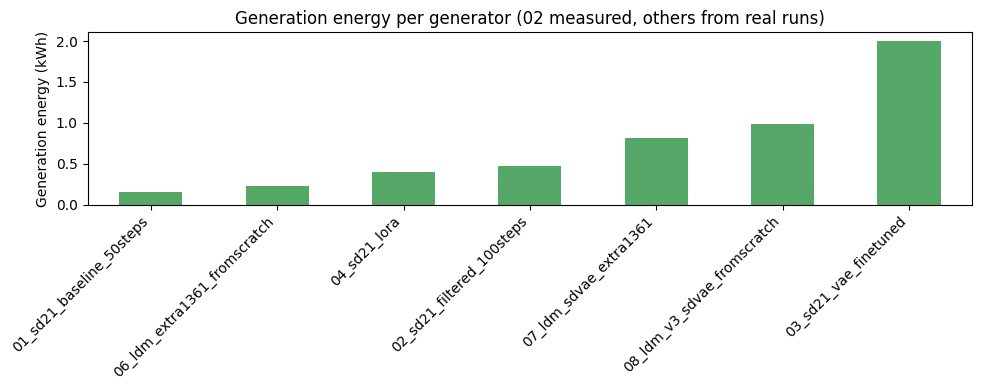

In [5]:
gen_hours = by_phase['generation'].copy()
gen_energy_pool = gen_hours * POWER_KW
table = pd.DataFrame({'generation_hours': gen_hours, 'generation_kwh': gen_energy_pool}).loc[totals.index]
fig, ax = plt.subplots(figsize=(10, 4))
table['generation_kwh'].sort_values().plot.bar(ax=ax, color='#55A868')
ax.set_ylabel('Generation energy (kWh)'); ax.set_xlabel('')
ax.set_title('Generation energy per generator (02 measured, others from real runs)')
ax.tick_params(axis='x', labelrotation=45)
for lab in ax.get_xticklabels(): lab.set_ha('right')
fig.tight_layout(); fig.savefig(FIGURES / 'generation_efficiency.png', dpi=110)
table.round(3)

## Notes

- Energy is `wall-clock hours × 0.170 kW` (measured mean draw of the RTX 5060 Ti during real generation). This replaces CodeCarbon's `energy_kwh`, which is unreliable on this GPU. All experiments are put on the same GPU basis for a fair comparison.
- Only runs longer than 60 s are counted; shorter events are CodeCarbon restart appends with no real work.
- `02_sd21_filtered` generation is a controlled 100-image, 100-step measurement extrapolated to the 1361-image pool; its historical log conflated generation into the filtering phase.
- `05_ldm_basic_fromscratch` is an abandoned early experiment without a reliable energy log and is omitted; `01`/`03`/`04` are SD-based and `06`/`07`/`08` are LDM-based.